<a href="https://colab.research.google.com/github/jazminfuentesb/Proyecto_RRSM/blob/main/Proyecto_RRSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# =====================================================
# PASO 1 — IMPORTAR LIBRERÍAS
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO


# =====================================================
# PASO 2 — DEFINIR RUTA DEL ARCHIVO
# =====================================================
file_path = "/content/drive/MyDrive/Proyecto RRSM/GSE21942_series_matrix.txt"


# =====================================================
# PASO 3 — LEER ARCHIVO GEO SERIES MATRIX
# =====================================================
with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()


# =====================================================
# PASO 4 — ENCONTRAR INICIO Y FIN DE TABLA
# =====================================================
start_idx = None
end_idx = None

for i, line in enumerate(lines):

    # limpiar línea (quitar comillas y espacios)
    clean_line = line.strip().replace('"', '')

    # detectar encabezado real
    if "ID_REF" in clean_line:
        start_idx = i

    # detectar final de tabla
    if "!series_matrix_table_end" in clean_line:
        end_idx = i
        break


# =====================================================
# PASO 5 — VERIFICACIÓN
# =====================================================
print("Inicio tabla:", start_idx)
print("Fin tabla:", end_idx)

if start_idx is None:
    raise ValueError("No se encontró el encabezado ID_REF")

if end_idx is None:
    raise ValueError("No se encontró !series_matrix_table_end")


# =====================================================
# PASO 6 — CREAR DATAFRAME
# =====================================================
expression_data = ''.join(lines[start_idx:end_idx])

df = pd.read_csv(
    StringIO(expression_data),
    sep='\t'
)


# =====================================================
# PASO 7 — EXPLORAR DATASET
# =====================================================
print("Dimensiones del dataset:")
print(df.shape)

df.head()

Inicio tabla: 58
Fin tabla: 54734
Dimensiones del dataset:
(54675, 30)


,ID_REF,GSM545818,GSM545819,GSM545820,GSM545821,GSM545822,GSM545823,GSM545824,GSM545825,GSM545826,...,GSM545837,GSM545838,GSM545839,GSM545840,GSM545841,GSM545842,GSM545843,GSM545844,GSM545845,GSM545846
0,1007_s_at,63.7,67.0,84.7,55.9,72.8,74.8,51.6,67.8,64.8,...,87.8,94.0,81.6,79.5,79.1,78.0,67.7,73.0,45.4,65.7
1,1053_at,157.2,153.0,143.5,136.3,153.9,134.6,122.7,135.0,134.4,...,93.5,116.1,145.1,107.0,110.7,107.4,149.4,123.1,140.7,107.3
2,117_at,262.0,349.7,226.2,204.6,245.8,220.2,378.6,273.0,262.0,...,143.1,214.7,592.6,172.1,181.9,254.4,240.6,260.4,326.1,327.2
3,121_at,61.2,46.1,59.6,51.1,61.7,60.9,58.6,58.9,57.4,...,58.7,60.7,59.4,72.9,58.2,56.7,58.7,56.7,66.6,58.8
4,1255_g_at,6.0,6.0,6.1,6.0,5.9,6.2,6.0,6.1,6.0,...,6.1,6.5,6.4,6.1,5.9,6.1,6.1,6.1,6.1,6.1


In [13]:
# =====================================================
# PASO 8 — EXPLORAR COLUMNAS DEL DATASET
# =====================================================

print("Columnas disponibles:\n")
print(df.columns.tolist())

Columnas disponibles:

['ID_REF', 'GSM545818', 'GSM545819', 'GSM545820', 'GSM545821', 'GSM545822', 'GSM545823', 'GSM545824', 'GSM545825', 'GSM545826', 'GSM545827', 'GSM545828', 'GSM545829', 'GSM545830', 'GSM545831', 'GSM545832', 'GSM545833', 'GSM545834', 'GSM545835', 'GSM545836', 'GSM545837', 'GSM545838', 'GSM545839', 'GSM545840', 'GSM545841', 'GSM545842', 'GSM545843', 'GSM545844', 'GSM545845', 'GSM545846']


In [14]:
# =====================================================
# PASO 9 — IDENTIFICAR PLATAFORMA DEL DATASET
# =====================================================

for line in lines[:60]:
    if "platform_id" in line.lower():
        print(line)

!Series_platform_id	"GPL570"

!Sample_platform_id	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"	"GPL570"



In [16]:
# =====================================================
# PASO 10 — DESCARGAR ANOTACIÓN GPL570 (CORREGIDO)
# =====================================================
import pandas as pd

url = "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL570/annot/GPL570.annot.gz"

annotation_df = pd.read_csv(
    url,
    sep="\t",
    compression="gzip",
    skiprows=27,      # saltar encabezados raros GEO
    low_memory=False
)

print("Dimensiones anotación:")
print(annotation_df.shape)

print("\nColumnas disponibles:")
print(annotation_df.columns.tolist())

annotation_df.head()

Dimensiones anotación:
(54676, 21)

Columnas disponibles:
['ID', 'Gene title', 'Gene symbol', 'Gene ID', 'UniGene title', 'UniGene symbol', 'UniGene ID', 'Nucleotide Title', 'GI', 'GenBank Accession', 'Platform_CLONEID', 'Platform_ORF', 'Platform_SPOTID', 'Chromosome location', 'Chromosome annotation', 'GO:Function', 'GO:Process', 'GO:Component', 'GO:Function ID', 'GO:Process ID', 'GO:Component ID']


,ID,Gene title,Gene symbol,Gene ID,UniGene title,UniGene symbol,UniGene ID,Nucleotide Title,GI,GenBank Accession,...,Platform_ORF,Platform_SPOTID,Chromosome location,Chromosome annotation,GO:Function,GO:Process,GO:Component,GO:Function ID,GO:Process ID,GO:Component ID
0,1007_s_at,microRNA 4640///discoidin domain receptor tyro...,MIR4640///DDR1,100616237///780,NaN,NaN,NaN,"Human receptor tyrosine kinase DDR gene, compl...",1753221.0,U48705,...,NaN,NaN,6p21.3,"Chromosome 6, NC_000006.12 (30890883..30890972...",ATP binding///collagen binding///collagen bind...,branching involved in mammary gland duct morph...,basolateral plasma membrane///extracellular ex...,GO:0005524///GO:0005518///GO:0005518///GO:0046...,GO:0060444///GO:0007155///GO:0038063///GO:0038...,GO:0016323///GO:0070062///GO:0005615///GO:0005...
1,1053_at,replication factor C subunit 2,RFC2,5982,NaN,NaN,NaN,"Human replication factor C, 40-kDa subunit (A1...",1590810.0,M87338,...,NaN,NaN,7q11.23,"Chromosome 7, NC_000007.14 (74231502..74254458...",ATP binding///contributes_to DNA clamp loader ...,"DNA damage response, detection of DNA damage//...",Ctf18 RFC-like complex///DNA replication facto...,GO:0005524///contributes_to GO:0003689///GO:00...,GO:0042769///GO:0006260///GO:0070987///GO:0042...,GO:0031390///GO:0005663///GO:0005654
2,117_at,heat shock protein family A (Hsp70) member 6,HSPA6,3310,NaN,NaN,NaN,Human heat-shock protein HSP70B' gene,35221.0,X51757,...,NaN,NaN,1q23,"Chromosome 1, NC_000001.11 (161524540..161526897)","ATP binding///ATPase activity, coupled///enzym...",NOT cellular heat acclimation///cellular respo...,colocalizes_with COP9 signalosome///blood micr...,GO:0005524///GO:0042623///GO:0019899///GO:0031...,NOT GO:0070370///GO:0034605///GO:0034605///GO:...,colocalizes_with GO:0008180///GO:0072562///GO:...
3,121_at,paired box 8,PAX8,7849,NaN,NaN,NaN,H.sapiens Pax8 mRNA,38425.0,X69699,...,NaN,NaN,2q13,"Chromosome 2, NC_000002.12 (113215997..1132789...",DNA binding///DNA binding///RNA polymerase II ...,anatomical structure morphogenesis///branching...,nucleoplasm///nucleoplasm///nucleus,GO:0003677///GO:0003677///GO:0000978///GO:0000...,GO:0009653///GO:0001658///GO:0071371///GO:0007...,GO:0005654///GO:0005654///GO:0005634
4,1255_g_at,guanylate cyclase activator 1A,GUCA1A,2978,NaN,NaN,NaN,Homo sapiens guanylate cyclase activating prot...,623404.0,L36861,...,NaN,NaN,6p21.1,"Chromosome 6, NC_000006.12 (42155377..42180083)",calcium ion binding///calcium sensitive guanyl...,cellular response to calcium ion///phototransd...,photoreceptor disc membrane///photoreceptor in...,GO:0005509///GO:0008048///GO:0030249,GO:0071277///GO:0007602///GO:0031284///GO:0022...,GO:0097381///GO:0001917///GO:0005886


In [17]:
# =====================================================
# PASO 11 — EXTRAER PANEL INMUNOLÓGICO RRMS
# =====================================================

# Panel inmunológico seleccionado
immune_genes = [
    "IL17A",
    "IFNG",
    "TNF",
    "FOXP3",
    "IL10",
    "TNFSF14",
    "MBP",
    "MOG"
]

# Seleccionar solo columnas necesarias
annotation_subset = annotation_df[
    ["ID", "Gene symbol"]
].copy()

# Renombrar para hacer merge limpio
annotation_subset.rename(
    columns={
        "ID": "ID_REF",
        "Gene symbol": "Gene_symbol"
    },
    inplace=True
)

# Unir expresión + anotación
merged_df = pd.merge(
    df,
    annotation_subset,
    on="ID_REF",
    how="left"
)

# Filtrar genes del panel
immune_df = merged_df[
    merged_df["Gene_symbol"].isin(immune_genes)
]

# Ver resultado
print("Genes encontrados:")
print(immune_df["Gene_symbol"].unique())

print("\nDimensiones:")
print(immune_df.shape)

immune_df.head()

Genes encontrados:
['MBP' 'MOG' 'TNF' 'IL10' 'TNFSF14' 'IL17A' 'IFNG' 'FOXP3']

Dimensiones:
(23, 31)


,ID_REF,GSM545818,GSM545819,GSM545820,GSM545821,GSM545822,GSM545823,GSM545824,GSM545825,GSM545826,...,GSM545838,GSM545839,GSM545840,GSM545841,GSM545842,GSM545843,GSM545844,GSM545845,GSM545846,Gene_symbol
1649,1554544_a_at,581.2,223.5,314.6,422.8,589.2,134.7,653.3,163.6,355.2,...,158.0,652.8,419.1,603.1,282.8,388.5,490.4,318.6,490.6,MBP
2586,1555807_a_at,5.1,5.0,5.1,5.1,5.0,5.2,5.0,5.5,5.1,...,5.6,5.4,5.1,5.1,5.2,5.1,5.1,5.1,5.1,MOG
15436,205989_s_at,7.9,7.9,8.0,8.6,7.7,8.2,7.8,8.1,7.8,...,8.5,8.4,8.1,7.5,8.3,7.3,8.0,7.4,8.0,MOG
16559,207113_s_at,21.8,24.3,15.1,18.8,21.7,10.9,15.8,12.1,10.4,...,16.8,25.3,14.8,12.6,9.3,12.5,10.9,18.8,33.1,TNF
16767,207323_s_at,8.6,8.1,8.6,8.5,10.7,10.3,11.4,8.5,8.8,...,12.0,10.4,12.9,9.2,8.6,8.6,8.5,7.7,8.3,MBP


In [18]:
# =====================================================
# PASO 12 — CALCULAR EXPRESIÓN MEDIA CONTROL vs MS
# =====================================================

# Muestras del dataset
sample_columns = df.columns[1:]  # excluir ID_REF

# Según GEO GSE21942:
# primeros 15 = controles
# últimos 14 = MS
control_samples = sample_columns[:15]
ms_samples = sample_columns[15:]

# Calcular medias por probe
immune_df["Control_mean"] = immune_df[
    control_samples
].mean(axis=1)

immune_df["MS_mean"] = immune_df[
    ms_samples
].mean(axis=1)

# Agrupar por gen (si hay múltiples probes)
gene_summary = immune_df.groupby(
    "Gene_symbol"
)[["Control_mean", "MS_mean"]].mean()

# Ver resultados
gene_summary = gene_summary.reset_index()

print(gene_summary)

gene_summary

  Gene_symbol  Control_mean     MS_mean
0       FOXP3      9.517778   10.033333
1        IFNG     89.586667   50.107143
2        IL10      7.500000    7.285714
3       IL17A      7.086667    7.132143
4         MBP    289.069630  289.573810
5         MOG      6.396667    6.553571
6         TNF     17.253333   17.971429
7     TNFSF14     64.096667   41.389286


/tmp/ipykernel_1580/2139876193.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  immune_df["Control_mean"] = immune_df[
/tmp/ipykernel_1580/2139876193.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  immune_df["MS_mean"] = immune_df[


,Gene_symbol,Control_mean,MS_mean
0,FOXP3,9.517778,10.033333
1,IFNG,89.586667,50.107143
2,IL10,7.500000,7.285714
3,IL17A,7.086667,7.132143
4,MBP,289.069630,289.573810
5,MOG,6.396667,6.553571
6,TNF,17.253333,17.971429
7,TNFSF14,64.096667,41.389286


In [19]:
# =====================================================
# PASO 13 — SIMULACIÓN POST-VACUNA RRMS
# =====================================================

# Copia limpia
simulation_df = gene_summary.copy()

# Nueva columna
simulation_df["Post_vaccine"] = simulation_df["MS_mean"]

# Reglas biológicas conceptuales
for i, row in simulation_df.iterrows():

    gene = row["Gene_symbol"]
    value = row["MS_mean"]

    # genes proinflamatorios ↓20%
    if gene in ["TNF", "IL17A", "IFNG"]:
        simulation_df.loc[i, "Post_vaccine"] = value * 0.80

    # genes tolerogénicos ↑20%
    elif gene in ["FOXP3", "IL10"]:
        simulation_df.loc[i, "Post_vaccine"] = value * 1.20

    # autoantígenos ↓10%
    elif gene in ["MBP", "MOG"]:
        simulation_df.loc[i, "Post_vaccine"] = value * 0.90

    # TNFSF14 normalización suave ↑15%
    elif gene == "TNFSF14":
        simulation_df.loc[i, "Post_vaccine"] = value * 1.15

# Ver resultado
simulation_df

,Gene_symbol,Control_mean,MS_mean,Post_vaccine
0,FOXP3,9.517778,10.033333,12.040000
1,IFNG,89.586667,50.107143,40.085714
2,IL10,7.500000,7.285714,8.742857
3,IL17A,7.086667,7.132143,5.705714
4,MBP,289.069630,289.573810,260.616429
5,MOG,6.396667,6.553571,5.898214
6,TNF,17.253333,17.971429,14.377143
7,TNFSF14,64.096667,41.389286,47.597679


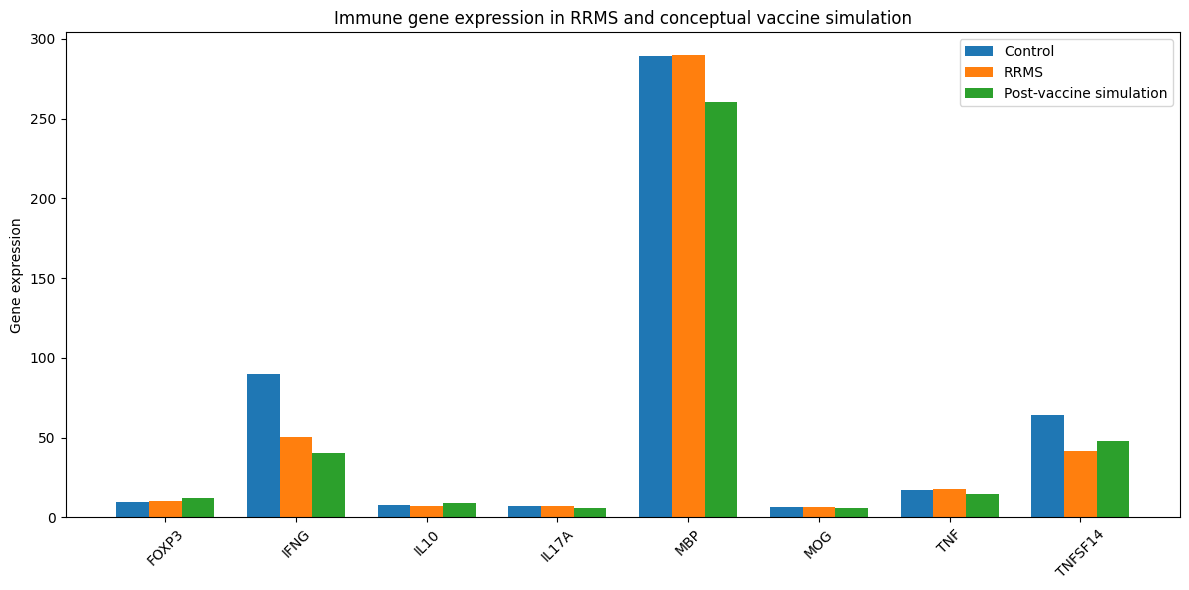

In [20]:
# =====================================================
# PASO 14 — VISUALIZACIÓN CONTROL vs RRMS vs POST-VACUNA
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

# Datos
genes = simulation_df["Gene_symbol"]

control = simulation_df["Control_mean"]
ms = simulation_df["MS_mean"]
post_vaccine = simulation_df["Post_vaccine"]

# Posiciones
x = np.arange(len(genes))
width = 0.25

# Figura
plt.figure(figsize=(12,6))

plt.bar(
    x - width,
    control,
    width,
    label="Control"
)

plt.bar(
    x,
    ms,
    width,
    label="RRMS"
)

plt.bar(
    x + width,
    post_vaccine,
    width,
    label="Post-vaccine simulation"
)

# Diseño
plt.xticks(x, genes, rotation=45)
plt.ylabel("Gene expression")
plt.title("Immune gene expression in RRMS and conceptual vaccine simulation")
plt.legend()

plt.tight_layout()
plt.show()

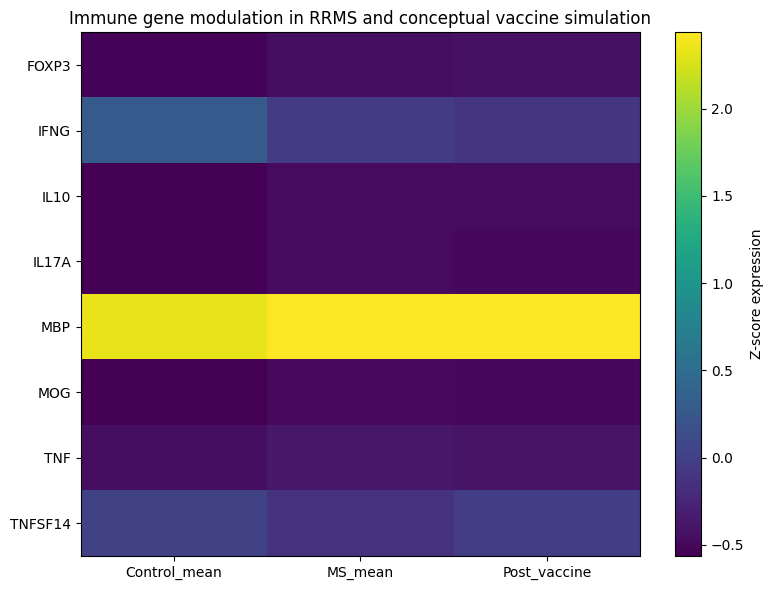

In [21]:
 # =====================================================
# PASO 15 — HEATMAP INMUNOGENÉTICO
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd

# Preparar datos
heatmap_df = simulation_df[
    ["Gene_symbol", "Control_mean", "MS_mean", "Post_vaccine"]
].copy()

heatmap_df.set_index("Gene_symbol", inplace=True)

# Normalización simple (z-score)
heatmap_normalized = (
    heatmap_df - heatmap_df.mean()
) / heatmap_df.std()

# Figura
plt.figure(figsize=(8,6))

plt.imshow(
    heatmap_normalized,
    aspect='auto'
)

# Etiquetas
plt.xticks(
    range(len(heatmap_normalized.columns)),
    heatmap_normalized.columns
)

plt.yticks(
    range(len(heatmap_normalized.index)),
    heatmap_normalized.index
)

plt.colorbar(label='Z-score expression')

plt.title(
    "Immune gene modulation in RRMS and conceptual vaccine simulation"
)

plt.tight_layout()
plt.show()

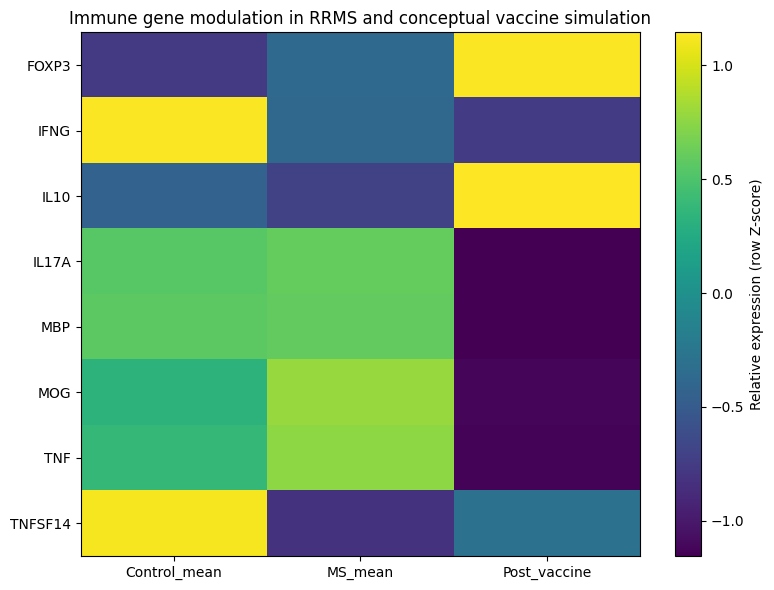

In [22]:
# =====================================================
# PASO 16 — HEATMAP NORMALIZADO POR GEN
# =====================================================

import matplotlib.pyplot as plt

# Preparar datos
heatmap_df = simulation_df[
    ["Gene_symbol", "Control_mean", "MS_mean", "Post_vaccine"]
].copy()

heatmap_df.set_index("Gene_symbol", inplace=True)

# Z-score por FILA (por gen)
heatmap_rowwise = heatmap_df.sub(
    heatmap_df.mean(axis=1),
    axis=0
).div(
    heatmap_df.std(axis=1),
    axis=0
)

# Figura
plt.figure(figsize=(8,6))

plt.imshow(
    heatmap_rowwise,
    aspect="auto"
)

# Etiquetas
plt.xticks(
    range(len(heatmap_rowwise.columns)),
    heatmap_rowwise.columns
)

plt.yticks(
    range(len(heatmap_rowwise.index)),
    heatmap_rowwise.index
)

plt.colorbar(label="Relative expression (row Z-score)")

plt.title(
    "Immune gene modulation in RRMS and conceptual vaccine simulation"
)

plt.tight_layout()
plt.show()

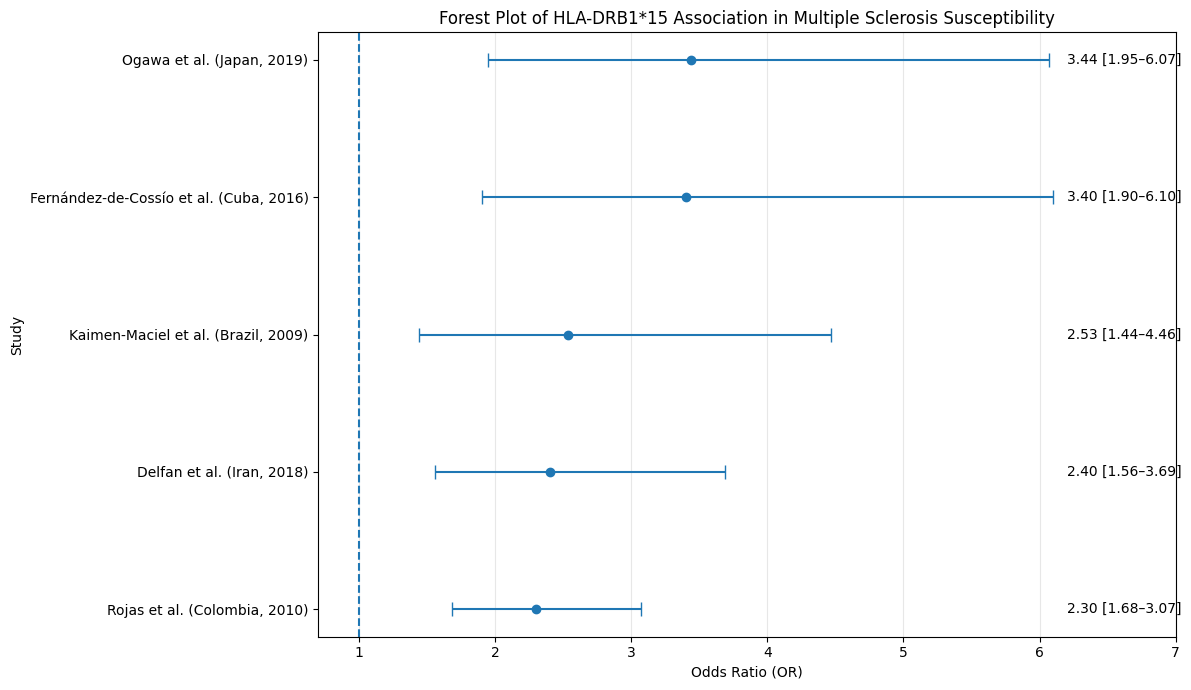

In [24]:
# =====================================================
# PASO 19 — FOREST PLOT ESTILO PAPER
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# DATOS
# ==========================
forest_df = pd.DataFrame({

    "Study": [
        "Delfan et al. (Iran, 2018)",
        "Kaimen-Maciel et al. (Brazil, 2009)",
        "Rojas et al. (Colombia, 2010)",
        "Fernández-de-Cossío et al. (Cuba, 2016)",
        "Ogawa et al. (Japan, 2019)"
    ],

    "OR": [
        2.40,
        2.5343,
        2.30,
        3.40,
        3.44
    ],

    "CI_lower": [
        1.561,
        1.4387,
        1.68,
        1.90,
        1.95
    ],

    "CI_upper": [
        3.690,
        4.4643,
        3.07,
        6.10,
        6.07
    ]
})


# ==========================
# ORDENAR POR OR
# ==========================
forest_df = forest_df.sort_values("OR")


# ==========================
# ERRORES
# ==========================
lower_error = forest_df["OR"] - forest_df["CI_lower"]
upper_error = forest_df["CI_upper"] - forest_df["OR"]


# ==========================
# FIGURA
# ==========================
plt.figure(figsize=(12,7))

y_positions = np.arange(len(forest_df))


plt.errorbar(
    forest_df["OR"],
    y_positions,
    xerr=[lower_error, upper_error],
    fmt='o',
    capsize=5
)


# Línea de no efecto
plt.axvline(
    x=1,
    linestyle='--'
)


# Etiquetas eje y
plt.yticks(
    y_positions,
    forest_df["Study"]
)


# Agregar texto OR + IC95%
for i, row in enumerate(forest_df.itertuples()):

    plt.text(
        6.2,
        i,
        f'{row.OR:.2f} [{row.CI_lower:.2f}–{row.CI_upper:.2f}]',
        va='center'
    )


plt.xlabel("Odds Ratio (OR)")
plt.ylabel("Study")

plt.title(
    "Forest Plot of HLA-DRB1*15 Association in Multiple Sclerosis Susceptibility"
)

plt.grid(axis='x', alpha=0.3)

plt.xlim(0.7, 7)

plt.tight_layout()
plt.show()

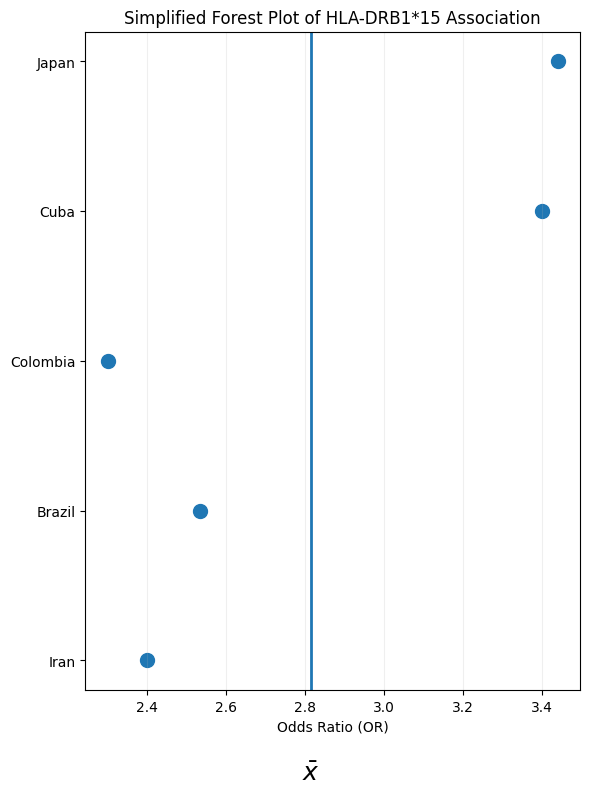

Mean OR (x̄): 2.81


In [27]:
# =====================================================
# PASO 20 — FOREST PLOT SIMPLIFICADO (ESTILO PROFESOR)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =====================================================
# DATOS
# =====================================================
forest_simple = pd.DataFrame({

    "Study": [
        "Iran",
        "Brazil",
        "Colombia",
        "Cuba",
        "Japan"
    ],

    "OR": [
        2.40,
        2.5343,
        2.30,
        3.40,
        3.44
    ]
})


# =====================================================
# PROMEDIO GLOBAL
# =====================================================
mean_or = forest_simple["OR"].mean()


# =====================================================
# FIGURA
# =====================================================
plt.figure(figsize=(6,8))

# Posiciones verticales
y_positions = np.arange(len(forest_simple))

# Puntos de estudios
plt.scatter(
    forest_simple["OR"],
    y_positions,
    s=100
)

# Línea vertical del promedio
plt.axvline(
    mean_or,
    linewidth=2
)

# Etiquetas estudios
plt.yticks(
    y_positions,
    forest_simple["Study"]
)

# Etiqueta promedio
plt.text(
    mean_or,
    -0.8,
    r'$\bar{x}$',
    fontsize=18,
    ha='center'
)

# Diseño limpio estilo pizarrón
plt.xlabel("Odds Ratio (OR)")
plt.title(
    "Simplified Forest Plot of HLA-DRB1*15 Association"
)

plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()


# =====================================================
# MOSTRAR PROMEDIO
# =====================================================
print(f"Mean OR (x̄): {mean_or:.2f}")